In [18]:
import pandas as pd
veri = pd.read_csv("diabetes_dataset.csv")
veri.isna().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [20]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [22]:
veri.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [ ]:
veri[veri["diabetes_stage"]=="No Diabetes"]

In [ ]:
veri.select_dtypes(include=["int64","float64"]).columns

In [ ]:
cols =['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diagnosed_diabetes']

veri_temiz = veri.copy()

for i in cols:
    print(veri[i].max())
    
print("")

for i in cols:   
    print(veri[i].min())

In [ ]:
for i in cols:
    Q1 = veri[i].quantile(0.25)
    Q3 = veri[i].quantile(0.75)
    IQR = Q3-Q1
    alt = Q1-1.5*IQR
    ust = Q3+1.5*IQR
    veri_temiz = veri[(veri[i]>=alt)&(veri[i]<=ust)]

In [ ]:
for i in cols:
    print(veri_temiz[i].max())
    
print("")

for i in cols:   
    print(veri_temiz[i].min())

In [ ]:
veri.select_dtypes(include="object").columns

In [ ]:
X = veri_temiz.drop(["diagnosed_diabetes","education_level","income_level","employment_status","diabetes_stage"], axis=1)
y = veri_temiz["diagnosed_diabetes"]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cols =['gender', 'ethnicity','smoking_status']
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot, cols)],
           remainder="passthrough")
transformed_X = transformer.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train);

In [ ]:
model.score(X_test, y_test)

In [ ]:
y_preds = model.predict(X_test)

In [124]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [128]:
accuracy_score(y_true= y_test, y_pred= y_preds)

0.9176

In [130]:
f1_score(y_true= y_test, y_pred=y_preds)

0.9263167307520344

In [144]:
confusion_matrix(y_true=y_test, y_pred=y_preds)

In [152]:
pd.crosstab(y_test, 
           y_preds,
           rownames=["Actual Labels"],
           colnames=["Predicted Labels"]
)

Predicted Labels,0,1
Actual Labels,,
0,7993,9
1,1639,10359


In [156]:
y_probs = model.predict_proba(X_test)
y_probs

array([[0.19, 0.81],
       [0.87, 0.13],
       [0.89, 0.11],
       ...,
       [0.81, 0.19],
       [0.01, 0.99],
       [0.  , 1.  ]], shape=(20000, 2))

In [164]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
y_probs_positive = y_probs[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

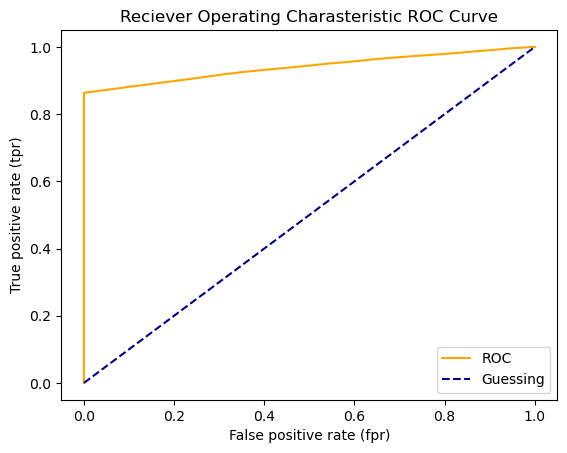

In [208]:
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    plt.plot(fpr,tpr, color="orange", label="ROC")
    plt.plot([0,1],[0,1], color="darkblue", linestyle="--", label="Guessing")

    plt.xlabel("False positive rate (fpr)")
    plt.ylabel("True positive rate (tpr)")
    plt.title("Reciever Operating Charasteristic ROC Curve")
    plt.legend()
    plt.show()

plot_roc_curve(fpr,tpr)

In [210]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_probs_positive)

np.float64(0.5035877745483991)

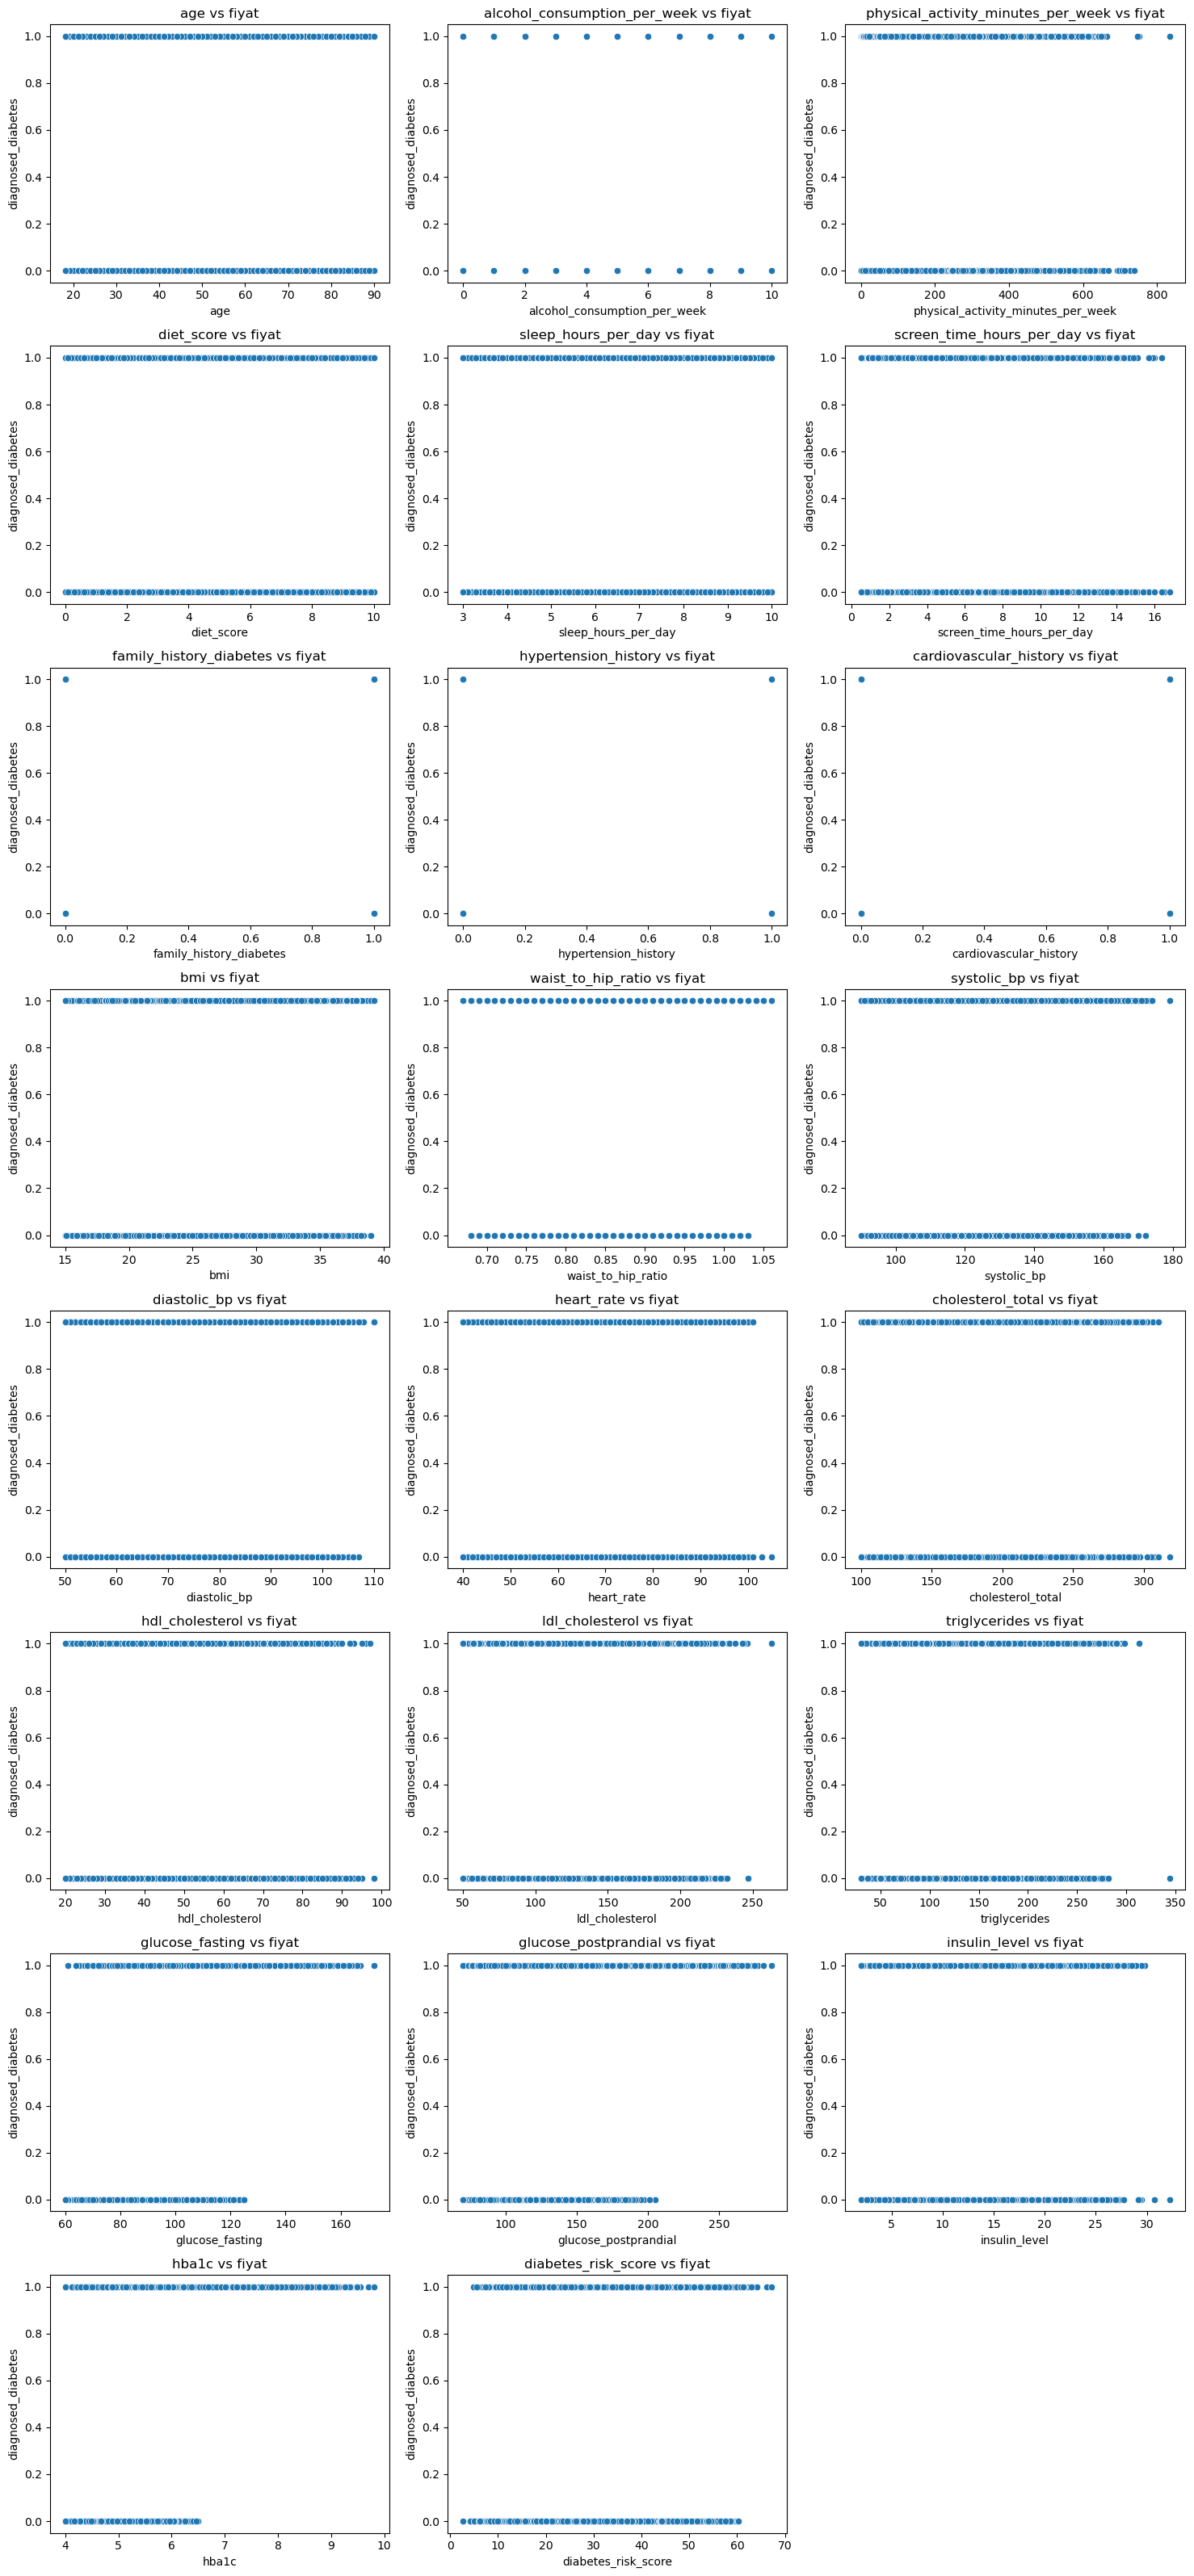

In [204]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sadece sayısal kolonları alıyoruz (target hariç)
numeric_cols = veri_temiz.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols.remove("diagnosed_diabetes")  # hedef kolon

# Kaç plot olacak
n_cols = 3  # satır başına 3 plot
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # toplam satır sayısı

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(data=veri_temiz, x=col, y="diagnosed_diabetes", ax=axes[i])
    axes[i].set_title(f"{col} vs fiyat")

# Kalan boş subplotları sil
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Veri temizlenmeden 

In [176]:
X = veri.drop(["diagnosed_diabetes","diabetes_stage"],axis=1)
y = veri["diagnosed_diabetes"]

In [180]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cols =['gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status']
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot, cols)],
           remainder="passthrough")
transformed_X = transformer.fit_transform(X)

In [194]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train);
model.score(X_test, y_test)

0.92455

In [187]:
y_preds = model.predict(X_test)

In [189]:
confusion_matrix(y_true=y_test, y_pred=y_preds)

array([[ 7975,    20],
       [ 1542, 10463]])

In [34]:
7945+10463

18408